In [6]:
# importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: xlabel='skill_count', ylabel='skill_pay'>

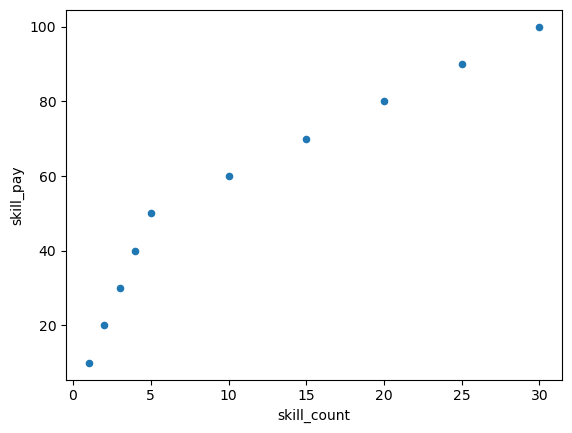

In [4]:
data = {
    'job_skills': ['python','sql','java','c++','c#','javascript','html','css','php','ruby'],
    'skill_count': [30,25,20,15,10,5,4,3,2,1],
    'skill_pay': [100,90,80,70,60,50,40,30,20,10]
}

df =pd.DataFrame(data)

df.plot(kind='scatter', x='skill_count', y='skill_pay')

In [7]:
df = df[df['job_title_short'] == 'Data Analyst']

In [9]:
df_exploded = df.explode('job_skills')

In [16]:
df_scatter = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)
df_scatter = df_scatter.sort_values(by='skill_count', ascending=False).head(10)
df_scatter

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


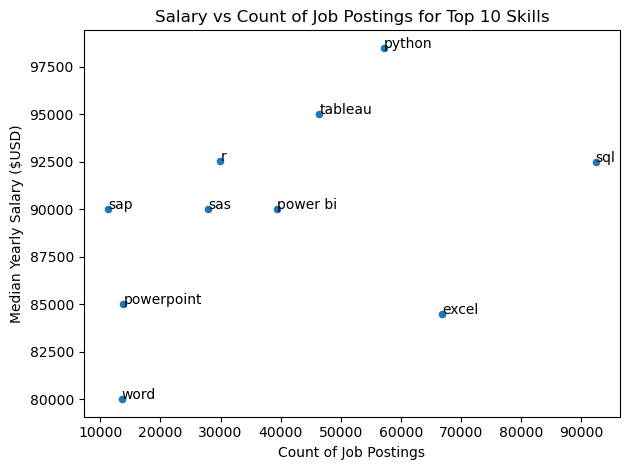

In [40]:
df_scatter.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs Count of Job Postings for Top 10 Skills')
plt.tight_layout()
for i, txt in enumerate(df_scatter.index):
    plt.text(df_scatter['skill_count'].iloc[i],df_scatter['median_salary'].iloc[i], txt)

plt.show()